In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')


In [ ]:
df = pd.read_csv('/content/final_dataset_2022_2024.csv', index_col=0)
df.index = pd.to_datetime(df.index, dayfirst=True)
df = df.sort_index()

print("Dataset loaded")
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print(f"From: {df.index.min().date()}")
print(f"To: {df.index.max().date()}")

Dataset loaded
Rows: 52461
Columns: 36
From: 2022-01-01
To: 2024-12-31


In [ ]:
# What we want to predict
target = 'demand_mw'

# Columns we do NOT use as features
cols_to_drop = [
    'demand_mw',        # this is the target
    'demand_lag_1',     # too close — would cause data leakage
    'minute',           # already captured in halfhour_slot
]

# All remaining columns are features
feature_cols = [col for col in df.columns if col not in cols_to_drop]

print(f"Target: {target}")
print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Target: demand_mw
Number of features: 33
Features: ['co2_emission', 'co2_intensity', 'wind_mw', 'temp_c', 'precip_mm', 'wind_speed_kmh', 'humidity_pct', 'dewpoint_c', 'surface_pressure_hpa', 'event_flag', 'event_intensity', 'num_events', 'is_public_holiday', 'hour', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'is_weekend', 'halfhour_slot', 'temp_squared', 'wind_chill', 'wind_penetration', 'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos', 'demand_lag_24h', 'demand_lag_168h', 'demand_rolling_24h_mean']


In [ ]:
# Split into chronological train (2022-2023) and test (2024) sets
train = df[df.index.year.isin([2022, 2023])].dropna(subset=feature_cols + [target])
test  = df[df.index.year == 2024].dropna(subset=feature_cols + [target])

X_train = train[feature_cols]
y_train = train[target]

X_test = test[feature_cols]
y_test = test[target]

print(f"Training set: {X_train.shape[0]:,} rows — {train.index.min().date()} to {train.index.max().date()}")
print(f"Test set:     {X_test.shape[0]:,} rows — {test.index.min().date()} to {test.index.max().date()}")

Training set: 34,617 rows — 2022-01-08 to 2023-12-31
Test set:     17,224 rows — 2024-01-01 to 2024-12-31


In [ ]:
# Train the baseline XGBoost model
model = xgb.XGBRegressor(
    n_estimators  = 500,
    learning_rate = 0.05,
    max_depth     = 6,
    random_state  = 42,
    verbosity     = 0
)

model.fit(X_train, y_train)

print("XGBoost model trained successfully")

XGBoost model trained successfully


In [ ]:
# Generate predictions on the 2024 test set
predictions = model.predict(X_test)

results = pd.DataFrame({
    'actual'           : y_test.values,
    'predicted'        : predictions,
    'event_flag'       : test['event_flag'].values,
    'is_public_holiday': test['is_public_holiday'].values,
}, index=test.index)

print("Predictions made")
print(f"Total predictions: {len(results):,}")

Predictions made
Total predictions: 17,224


In [ ]:
# Compute overall RMSE and MAE
overall_rmse = np.sqrt(mean_squared_error(results['actual'], results['predicted']))
overall_mae  = mean_absolute_error(results['actual'], results['predicted'])

print("Overall Model Performance on 2024 Test Set")
print(f"RMSE: {round(overall_rmse, 2)} MW")
print(f"MAE:  {round(overall_mae, 2)} MW")

Overall Model Performance on 2024 Test Set
RMSE: 116.69 MW
MAE:  88.53 MW


In [ ]:
# Compute RMSE/MAE separately for event days vs non-event days
event_results    = results[results['event_flag'] == 1]
nonevent_results = results[results['event_flag'] == 0]

event_rmse    = np.sqrt(mean_squared_error(event_results['actual'], event_results['predicted']))
event_mae     = mean_absolute_error(event_results['actual'], event_results['predicted'])

nonevent_rmse = np.sqrt(mean_squared_error(nonevent_results['actual'], nonevent_results['predicted']))
nonevent_mae  = mean_absolute_error(nonevent_results['actual'], nonevent_results['predicted'])

print("Performance on EVENT days:")
print(f"  RMSE: {round(event_rmse, 2)} MW")
print(f"  MAE:  {round(event_mae, 2)} MW")

print("\nPerformance on NON-EVENT days:")
print(f"  RMSE: {round(nonevent_rmse, 2)} MW")
print(f"  MAE:  {round(nonevent_mae, 2)} MW")

print("\nDifference (Event - Non-Event):")
print(f"  RMSE difference: {round(event_rmse - nonevent_rmse, 2)} MW")
print(f"  MAE difference:  {round(event_mae - nonevent_mae, 2)} MW")

Performance on EVENT days:
  RMSE: 98.6 MW
  MAE:  75.22 MW

Performance on NON-EVENT days:
  RMSE: 117.75 MW
  MAE:  89.38 MW

Difference (Event - Non-Event):
  RMSE difference: -19.15 MW
  MAE difference:  -14.16 MW


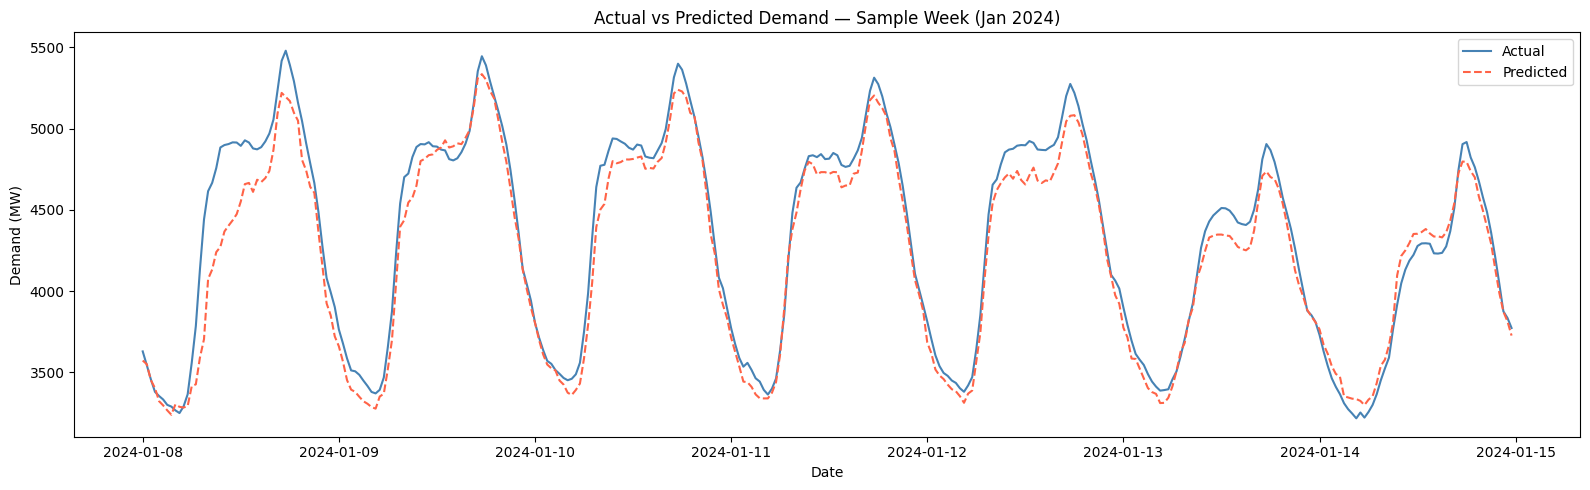

Chart saved


In [ ]:
# Plot actual vs predicted demand for a sample week
sample = results['2024-01-08':'2024-01-14']

plt.figure(figsize=(16, 5))
plt.plot(sample.index, sample['actual'],    color='steelblue', linewidth=1.5, label='Actual')
plt.plot(sample.index, sample['predicted'], color='tomato',    linewidth=1.5, label='Predicted', linestyle='--')
plt.title('Actual vs Predicted Demand — Sample Week (Jan 2024)')
plt.xlabel('Date')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/step3_chart1_sample_week.png', dpi=150)
plt.show()

print("Chart saved")

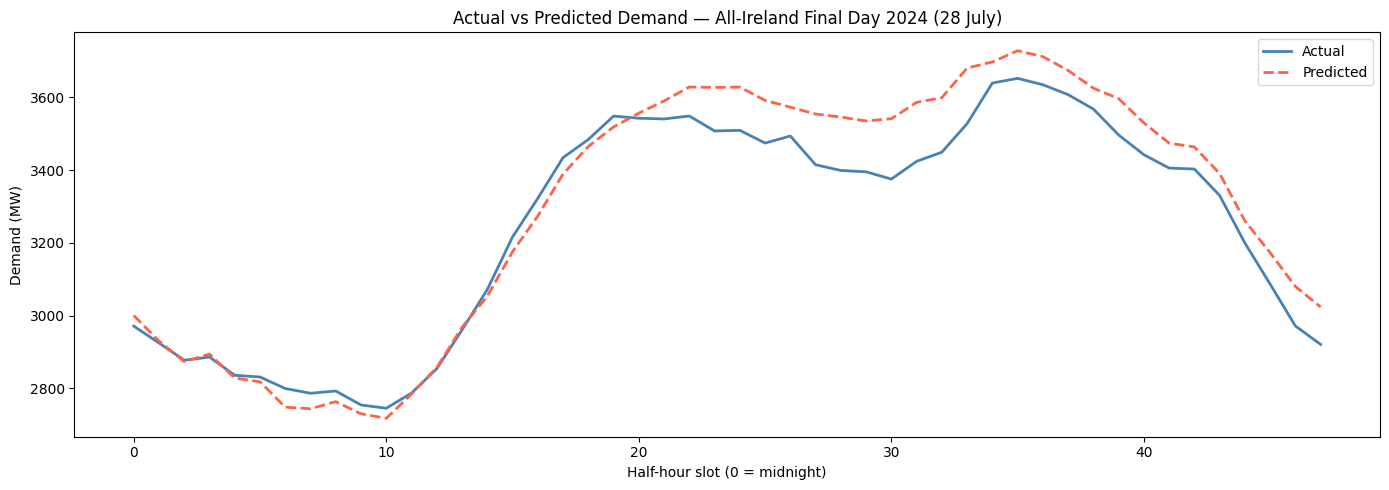

Chart saved


In [ ]:
# Chart — Plotting actual vs predicted demand on All-Ireland Final day 2024

event_date = pd.Timestamp('2024-07-28')
event_day  = results[results.index.date == event_date.date()]

plt.figure(figsize=(14, 5))
plt.plot(range(len(event_day)), event_day['actual'],    color='steelblue', linewidth=2, label='Actual')
plt.plot(range(len(event_day)), event_day['predicted'], color='tomato',    linewidth=2, label='Predicted', linestyle='--')
plt.title('Actual vs Predicted Demand — All-Ireland Final Day 2024 (28 July)')
plt.xlabel('Half-hour slot (0 = midnight)')
plt.ylabel('Demand (MW)')
plt.legend()
plt.tight_layout()
plt.savefig('/content/step3_chart2_event_day.png', dpi=150)
plt.show()

print("Chart saved")

In [ ]:
# Save the trained model and predictions
import joblib

model.save_model('/content/baseline_xgboost_model.json')
results.to_csv('/content/baseline_predictions.csv')

print("Model saved: baseline_xgboost_model.json")
print("Predictions saved: baseline_predictions.csv")

Model saved: baseline_xgboost_model.json
Predictions saved: baseline_predictions.csv
